Deep Learning Models: A collection of various deep learning architectures, models, & their implementations (`PyTorch` or `TensorFlow`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/deep-learning-models

In [1]:
!pip install watermark

In [2]:
!pip install torchinfo

In [3]:
%load_ext watermark
# %reload_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch

Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.11.13
IPython version      : 7.34.0

torch: 2.6.0+cu124



# DenseNet-121 Classifier on CIFAR-10

**Network Architecture:**

The network in this notebook is an implementation of the DenseNet-121 **[1]** architecture on the CIFAR-10 dataset to train an image classifier.  

![DenseNet-block](https://github.com/rasbt/deeplearning-models/blob/master/pytorch_ipynb/images/densenet/densenet-tab-1-dnet121.jpg?raw=1)

[Image Source](https://arxiv.org/pdf/1608.06993)

---
### **DenseNet:** Dense Block
The DenseNet paper introduced the idea that instead of connecting layers only to their immediate successors (like standard CNNs) or adding residual connections (like ResNet), **each layer should receive inputs from all preceding layers** and pass its own feature-maps to all subsequent layers. This helps alleviate the vanishing-gradient problem and encourages feature reuse. 

DenseNet is characterized by **Dense Blocks,** where each layer receives the concatenated feature maps of all preceding layers, and **Transition Layers,** which reduce the spatial dimensions and the number of channels between blocks. The following figure below illustrates the main concept of DenseNet: **within each "dense" block, each layer is connected with each previous layer -- the feature maps are concatenated.**



![DenseNet-block](https://github.com/rasbt/deeplearning-models/blob/master/pytorch_ipynb/images/densenet/densenet-fig-2.jpg?raw=1)

[Image Source](https://arxiv.org/pdf/1608.06993)


Note that this is somewhat related yet very different to ResNets. ResNets have skip connections approx. between every other layer (but don't connect all layers with each other). Also, ResNets skip connections work via addition

$$\mathbf{x}_{\ell}=H_{\ell}\left(\mathbf{X}_{\ell-1}\right)+\mathbf{X}_{\ell-1}$$

whereas $H_{\ell}(\cdot)$ can be a composite function  of operations such as Batch Normalization (BN), rectified linear units (ReLU), Pooling, or Convolution (Conv).

In DenseNets, all the previous feature maps $\mathbf{X}_{0}, \dots, \mathbf{X}_{\ell}-1$ of a feature map $\mathbf{X}_{\ell}$ are concatenated:

$$\mathbf{x}_{\ell}=H_{\ell}\left(\left[\mathbf{x}_{0}, \mathbf{x}_{1}, \ldots, \mathbf{x}_{\ell-1}\right]\right).$$

Furthermore, in this particular notebook, we are considering the DenseNet-121, which is depicted below:


<br><br>

---
**REFERENCES:**
1. Huang, G., Liu, Z., Van Der Maaten, L., & Weinberger, K. Q. (2017). [Densely connected convolutional networks.](https://arxiv.org/abs/1608.06993) In Proceedings of the IEEE conference on computer vision and pattern recognition (pp. 4700-4708).

In [4]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split

from torchinfo import summary

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np
import math
import time
import os
import random

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [5]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def set_deterministic():
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True
    torch.set_deterministic(True)

In [6]:
# Check if GPU is available and set the device
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    print("Num GPUs Available: ", num_gpus)
    for i in range(num_gpus):
        gpu_name = torch.cuda.get_device_name(i)
        print(f"GPU {i}: {gpu_name}")
else:
    print("No GPU available.")

Num GPUs Available:  2
GPU 0: Tesla T4
GPU 1: Tesla T4


---
# 0. Model Hyperparameters
---

In [7]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 123
BATCH_SIZE = 128 #256
LEARNING_RATE = 0.001
NUM_EPOCHS = 50
INPUT_SIZE = 32 # CIFAR-10 is 32x32
NUM_CLASSES = 10

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [8]:
set_all_seeds(RANDOM_SEED)

---
# 1. Data Preparation & Loading

---

In [9]:
# Mean and Std Dev for CIFAR-10 (3 channels)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2471, 0.2435, 0.2616)

# Data Augmentation (Crucial for VGG-16 on CIFAR-10)
train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4),   # Crop after padding
    transforms.RandomHorizontalFlip(),      # Flip
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD) # Mean Subtraction
])

# Test/Validation Transforms (No Augmentation)
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

# Load Datasets
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transforms)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transforms)

# Split training set into training and validation sets
train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

100%|██████████| 170M/170M [00:02<00:00, 78.6MB/s] 


In [10]:
# Check that shuffling works properly
# i.e., label indices should be in random order.
# Also, the label order should be different in the second
# epoch.

for images, labels in train_loader:  
    pass
print(labels[:10])

for images, labels in train_loader:  
    pass
print(labels[:10])

tensor([1, 5, 5, 4, 2, 8, 5, 2, 4, 2])
tensor([9, 2, 4, 3, 7, 5, 8, 6, 2, 8])


In [12]:
# Check that validation set and test sets are diverse
# i.e., that they contain all classes

for images, labels in val_loader:  
    pass
print(labels[:10])

for images, labels in test_loader:  
    pass
print(labels[:10])

tensor([1, 6, 5, 9, 9, 0, 6, 6])
tensor([7, 5, 8, 0, 8, 2, 7, 0, 3, 5])


---
# 2. Model Creation

---

In [13]:
class Bottleneck(nn.Module):
    def __init__(self, in_planes, growth_rate):
        super(Bottleneck, self).__init__()
        self.bn1 = nn.BatchNorm2d(in_planes)
        self.conv1 = nn.Conv2d(in_planes, 4*growth_rate, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(4*growth_rate)
        self.conv2 = nn.Conv2d(4*growth_rate, growth_rate, kernel_size=3, padding=1, bias=False)
    
    def forward(self, x):
        out = self.conv1(F.relu(self.bn1(x)))
        out = self.conv2(F.relu(self.bn2(out)))
        # Concatenate input with the output of this layer
        out = torch.cat([out, x], 1)
        return out

class Transition(nn.Module):
    def __init__(self, in_planes, out_planes):
        super(Transition, self).__init__()
        self.bn = nn.BatchNorm2d(in_planes)
        self.conv = nn.Conv2d(in_planes, out_planes, kernel_size=1, bias=False)

    def forward(self, x):
        out = self.conv(F.relu(self.bn(x)))
        out = F.avg_pool2d(out, 2)
        return out

class DenseNet(nn.Module):
    def __init__(self, block, nblocks, growth_rate=12, reduction=0.5, num_classes=10):
        super(DenseNet, self).__init__()
        self.growth_rate = growth_rate

        num_planes = 2*growth_rate
        self.conv1 = nn.Conv2d(3, num_planes, kernel_size=3, padding=1, bias=False)

        self.dense1 = self._make_dense_layers(block, num_planes, nblocks[0])
        num_planes += nblocks[0]*growth_rate
        out_planes = int(num_planes*reduction)
        self.trans1 = Transition(num_planes, out_planes)
        num_planes = out_planes

        self.dense2 = self._make_dense_layers(block, num_planes, nblocks[1])
        num_planes += nblocks[1]*growth_rate
        out_planes = int(num_planes*reduction)
        self.trans2 = Transition(num_planes, out_planes)
        num_planes = out_planes

        self.dense3 = self._make_dense_layers(block, num_planes, nblocks[2])
        num_planes += nblocks[2]*growth_rate

        self.bn = nn.BatchNorm2d(num_planes)
        self.linear = nn.Linear(num_planes, num_classes)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def _make_dense_layers(self, block, in_planes, nblock):
        layers = []
        for i in range(nblock):
            layers.append(block(in_planes, self.growth_rate))
            in_planes += self.growth_rate
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.trans1(self.dense1(out))
        out = self.trans2(self.dense2(out))
        out = self.dense3(out)
        out = F.avg_pool2d(F.relu(self.bn(out)), 8)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

def DenseNet121():
    return DenseNet(Bottleneck, [6, 12, 24, 16], growth_rate=32)

In [14]:
model = DenseNet121().to(device)

In [15]:
# Model parameter details
summary(model,
        input_size=(BATCH_SIZE, 3, INPUT_SIZE, INPUT_SIZE),
        # verbose=1,
        col_names=["input_size", "output_size", "num_params", "kernel_size", "mult_adds"]
       )

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape              Mult-Adds
DenseNet                                 [128, 3, 32, 32]          [128, 10]                 --                        --                        --
├─Conv2d: 1-1                            [128, 3, 32, 32]          [128, 64, 32, 32]         1,728                     [3, 3]                    226,492,416
├─Sequential: 1-2                        [128, 64, 32, 32]         [128, 256, 32, 32]        --                        --                        --
│    └─Bottleneck: 2-1                   [128, 64, 32, 32]         [128, 96, 32, 32]         --                        --                        --
│    │    └─BatchNorm2d: 3-1             [128, 64, 32, 32]         [128, 64, 32, 32]         128                       --                        16,384
│    │    └─Conv2d: 3-2                  [128, 64, 32, 32]         [128, 128, 32, 32]       

---
# 3. Model Training, Testing & Evaluation

---

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-4)
# optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9, weight_decay=5e-4) # Use weight decay (L2) to combat overfitting
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

def calculate_accuracy(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

# Training Loop
start_time = time.time()
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lrs': []}

print(f"Starting training on {device}...")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)

    train_loss = running_loss / len(train_subset)
    train_acc = calculate_accuracy(train_loader)
    
    # Calculate validation loss and accuracy
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
    
    val_loss /= len(val_subset)
    val_acc = calculate_accuracy(val_loader)
    
    # scheduler.step(val_loss)
    # current_lr = optimizer.param_groups[0]['lr']

    # Log metrics
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    # history['lrs'].append(current_lr)

    print(f'Epoch {epoch + 1}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.5f}, '
          f'Train Acc.: {train_acc:.2f}% | '
          f'Val Loss: {val_loss:.5f}, '
          f'Val Acc.: {val_acc:.2f}% | '
          # f'LR: {current_lr:.8f}')
         )

print('\nTotal Training Time: %.2f min' % ((time.time() - start_time)/60))

# --- Final Evaluation ---
test_accuracy = calculate_accuracy(test_loader)
print(f'\nTest Accuracy: {test_accuracy:.2f}%')

Starting training on cuda...
Epoch 1/50 | Train Loss: 0.76507, Train Acc.: 69.02% | Val Loss: 0.92106, Val Acc.: 67.30% | 
Epoch 2/50 | Train Loss: 0.64473, Train Acc.: 69.71% | Val Loss: 0.95157, Val Acc.: 68.96% | 
Epoch 3/50 | Train Loss: 0.57511, Train Acc.: 79.10% | Val Loss: 0.65987, Val Acc.: 78.00% | 
Epoch 4/50 | Train Loss: 0.52546, Train Acc.: 79.18% | Val Loss: 0.67954, Val Acc.: 77.34% | 
Epoch 5/50 | Train Loss: 0.48954, Train Acc.: 83.30% | Val Loss: 0.55165, Val Acc.: 80.70% | 
Epoch 6/50 | Train Loss: 0.45531, Train Acc.: 79.77% | Val Loss: 0.67802, Val Acc.: 76.46% | 
Epoch 7/50 | Train Loss: 0.42427, Train Acc.: 81.01% | Val Loss: 0.62767, Val Acc.: 77.92% | 
Epoch 8/50 | Train Loss: 0.40771, Train Acc.: 86.80% | Val Loss: 0.46966, Val Acc.: 83.60% | 
Epoch 9/50 | Train Loss: 0.39416, Train Acc.: 87.00% | Val Loss: 0.46760, Val Acc.: 84.50% | 
Epoch 10/50 | Train Loss: 0.37202, Train Acc.: 82.73% | Val Loss: 0.59864, Val Acc.: 79.42% | 
Epoch 11/50 | Train Loss: 0.35

KeyboardInterrupt: 

In [20]:
# --- Final Evaluation ---
test_accuracy = calculate_accuracy(test_loader)
print(f'\nTest Accuracy: {test_accuracy:.2f}%')


Test Accuracy: 88.84%


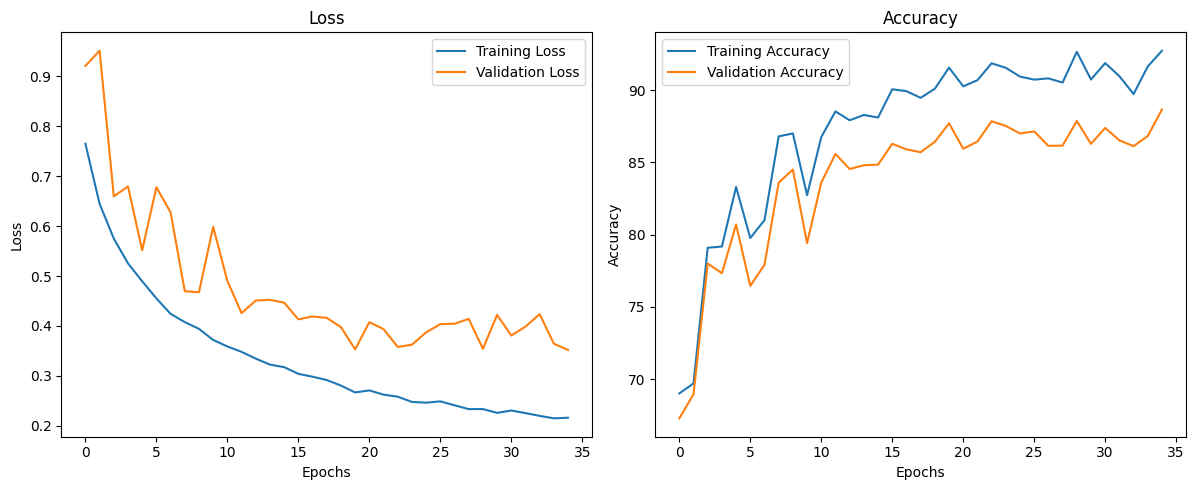

In [21]:
def plot_history(history):
    """
    Plots the training and validation loss, accuracy, and learning rate
    from a PyTorch history dictionary.

    Args:
        history (dict): Dictionary containing training metrics.
                        Expected keys: 'train_loss', 'val_loss', 'train_acc', 'val_acc', 'lrs'.
    """
    epochs = range(len(history['train_loss']))

    plt.figure(figsize=(18, 5))

    # Plot 1: Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], label='Training Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    # plt.grid(True)

    # Plot 2: Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['train_acc'], label='Training Accuracy')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    # plt.grid(True)

    plt.tight_layout()
    plt.show() 
    # plt.savefig() 

plot_history(history)

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def _compute_confusion_matrix(model, data_loader, device):
    """
    Computes a confusion matrix for the given model and data.
    Uses scikit-learn for robustness and speed.
    """
    model.eval()
    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for features, targets in data_loader:
            features = features.to(device)

            logits = model(features)
            _, predicted_labels = torch.max(logits, 1)

            # Move to CPU and convert to list/numpy immediately
            all_targets.extend(targets.view(-1).cpu().numpy())
            all_predictions.extend(predicted_labels.view(-1).cpu().numpy())

    return confusion_matrix(all_targets, all_predictions)

def _plot_confusion_matrix(mat, class_names):
    """
    Visualizes the confusion matrix using Seaborn for professional reporting.
    """
    plt.figure(figsize=(10, 8))
    sns.heatmap(mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix: MobileNetV2 on CIFAR-10')
    plt.show()

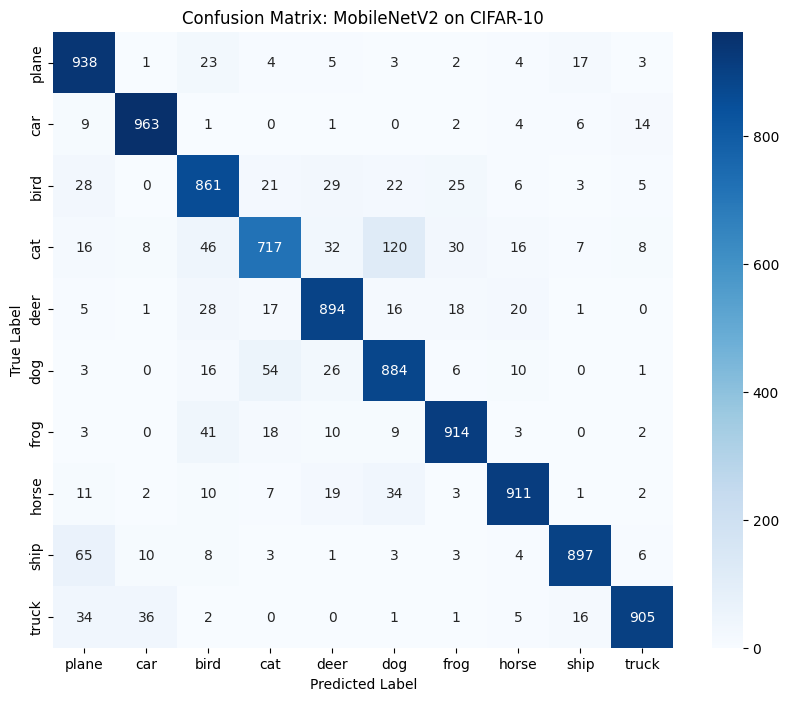

In [23]:
class_dict = {0: 'plane',
              1: 'car',
              2: 'bird',
              3: 'cat',
              4: 'deer',
              5: 'dog',
              6: 'frog',
              7: 'horse',
              8: 'ship',
              9: 'truck'}
_mat = _compute_confusion_matrix(model=model, data_loader=test_loader, device=device)
_plot_confusion_matrix(_mat, class_names=class_dict.values())

In [24]:
%watermark -iv

matplotlib : 3.7.2
numpy      : 1.26.4
pandas     : 2.2.3
seaborn    : 0.12.2
sklearn    : 1.2.2
torch      : 2.6.0+cu124
torchinfo  : 1.8.0
torchvision: 0.21.0+cu124

